# 🧹 Notebook 03 — DuckDB Enterprise Data Preprocessing Pipeline

<div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; margin: 10px 0;'>

**Production-Grade Preprocessing** — Processes 125M+ rows with < 2 GB RAM using DuckDB SQL streaming.

</div>

| Property | Value |
|:---|:---|
| 🏗️ **Architecture** | DuckDB SQL Streaming (train.parquet never enters pandas) |
| 💾 **Peak RAM** | < 2 GB (vs 12 GB with pure Pandas) |
| 📥 **Input** | 6 raw Parquet files (train, stores, items, oil, transactions, holidays) |
| 📤 **Output** | `clean_data.parquet` — fully merged, cleaned, downcasted |
| 📅 **Date Range** | Full history: 2013-01-01 → 2017-08-15 |
| 🖼️ **Plots Directory** | `output/03_preprocessing/` |

---

### 📑 Table of Contents

| # | Section | Purpose |
|:---:|:---|:---| 
| 1 | Environment Setup | Bootstrap project paths |
| 2 | Imports & DuckDB Init | Load modules, initialize DuckDB connection |
| 3 | Dataset Overview | Metadata scan of all 6 raw files (zero RAM) |
| 4 | Load Reference Tables | Small tables into pandas for inspection |
| 5 | Exploratory Visualizations | Distributions, trends, store/item analysis |
| 6 | Missing Value Imputation | Oil forward-fill, promotion NaN handling |
| 7 | Statistical Outlier Audit | DuckDB streaming quantile analysis |
| 8 | Outlier Visualization | Box plots and distribution charts |
| 9 | Holiday Processing | Transferred event handling |
| 10 | Oil Price Completion | Time-series reindexing |
| 11 | DuckDB SQL Pipeline | Multi-table JOIN + cleaning (core cell) |
| 12 | Output Validation | Schema, null checks, assertions |
| 13 | Post-Cleaning Visualizations | Before/after comparison charts |
| 14 | Final Summary & Cleanup | RAM report, resource cleanup |


---
## 1️⃣ Environment Setup & Project Bootstrap

> Adds the project root to `sys.path` so that `config.py` and `utils.py` are importable from `02_Notebooks/`.


In [47]:
# ============================================================
# PROJECT BOOTSTRAP — Ensure project root is on sys.path
# ============================================================
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'📁 Project Root: {PROJECT_ROOT}')


📁 Project Root: f:\


---
## 2️⃣ Imports, Configuration & DuckDB Initialization

> Import project modules and initialize the **singleton DuckDB connection** that will be reused throughout the notebook.

| Component | Purpose |
|:---|:---|
| `config.py` | Single source of truth for all project paths |
| `utils.py` | Enterprise infrastructure (DuckDB, PyArrow, memory management) |
| `DuckDB` | In-process analytical database — reads Parquet directly from disk |


In [48]:
import time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config, utils

# ── Plot Configuration ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = ['#667eea', '#764ba2', '#f093fb', '#f5576c', '#4facfe', '#43e97b', '#fa709a', '#fee140']

# Output directory for preprocessing plots
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '03_preprocessing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Initialize DuckDB ──
conn = utils.get_duckdb(memory_limit='2GB')

# ── Define Parquet paths ──
TRAIN_PQ  = config.TRAIN_PARQUET.as_posix()
STORES_PQ = config.STORES_PARQUET.as_posix()
ITEMS_PQ  = config.ITEMS_PARQUET.as_posix()
OIL_PQ    = config.OIL_PARQUET.as_posix()
TRANS_PQ  = config.TRANSACTIONS_PARQUET.as_posix()
HOLIDAYS_PQ = config.HOLIDAYS_PARQUET.as_posix()

utils.memory_checkpoint('After Imports')
print('✅ All imports loaded. DuckDB connection initialized.')
print(f'🖼️ Plots Directory: {OUTPUT_DIR}')


[2026-07-29 21:16:34] [INFO] 🦆 DuckDB connection opened | Memory: 2GB | Threads: 12
[2026-07-29 21:16:34] [INFO] 🧠 RAM Checkpoint [After Imports]: 0.09 GB
✅ All imports loaded. DuckDB connection initialized.
🖼️ Plots Directory: f:\NTI\Demand Forecasting System Backup\output\03_preprocessing


---
## 3️⃣ Dataset Overview & Metadata Scan (DuckDB — Zero RAM)

> Scan all 6 raw Parquet files **without loading them into pandas RAM**.
> DuckDB reads only Parquet metadata and sample rows directly from disk.

| Dataset | Description | Key Columns |
|:---|:---|:---|
| 🛒 `train` | Daily unit sales per store × item | `date`, `store_nbr`, `item_nbr`, `unit_sales` |
| 🏪 `stores` | Store metadata (54 stores) | `store_nbr`, `city`, `state`, `type`, `cluster` |
| 📦 `items` | Product metadata (~4,100 items) | `item_nbr`, `family`, `class`, `perishable` |
| 🛢️ `oil` | Daily oil prices (Ecuador's economy) | `date`, `dcoilwtico` |
| 💳 `transactions` | Daily store transaction counts | `date`, `store_nbr`, `transactions` |
| 🎉 `holidays` | Ecuador holiday calendar | `date`, `type`, `transferred` |


In [49]:
# DuckDB metadata scan — reads Parquet headers only, NOT full data
t0 = time.time()
datasets = {
    '🛒 train':       TRAIN_PQ,
    '🏪 stores':      STORES_PQ,
    '📦 items':       ITEMS_PQ,
    '🛢️ oil':         OIL_PQ,
    '💳 transactions': TRANS_PQ,
    '🎉 holidays':    HOLIDAYS_PQ,
}

summary_rows = []
for name, path in datasets.items():
    row_count = conn.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
    col_count = len(conn.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").fetchall())
    file_mb = Path(path).stat().st_size / (1024**2)
    summary_rows.append({'Dataset': name, 'Rows': f'{row_count:,}', 'Columns': col_count, 'Size (MB)': f'{file_mb:.1f}'})

summary_df = pd.DataFrame(summary_rows)
print(f'✅ Metadata scan completed in {time.time()-t0:.2f}s (Zero RAM used)')
display(summary_df.style.set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
utils.memory_checkpoint('After Metadata Scan')


✅ Metadata scan completed in 0.04s (Zero RAM used)


,Dataset,Rows,Columns,Size (MB)
0,🛒 train,"125,497,040",6,922.4
1,🏪 stores,54,5,0.0
2,📦 items,"4,100",4,0.0
3,🛢️ oil,"1,218",2,0.0
4,💳 transactions,"83,488",3,0.2
5,🎉 holidays,350,6,0.0


[2026-07-29 21:16:41] [INFO] 🧠 RAM Checkpoint [After Metadata Scan]: 0.10 GB


0.1024017333984375

---
## 4️⃣ Load Small Reference Tables into Pandas

> Load **only the small reference tables** into pandas for visual inspection.
> The massive `train.parquet` (125M+ rows) **stays on disk** — accessed exclusively via DuckDB.

| Table | Rows | RAM | Action |
|:---|---:|:---|:---|
| `train.parquet` | ~125M | ~8 GB | ❌ **Never loaded** — DuckDB only |
| `stores.parquet` | 54 | < 1 KB | ✅ Load into pandas |
| `items.parquet` | ~4,100 | < 1 MB | ✅ Load into pandas |
| `oil.parquet` | ~1,200 | < 1 MB | ✅ Load into pandas |
| `transactions.parquet` | ~83,000 | < 2 MB | ✅ Load into pandas |
| `holidays_events.parquet` | ~350 | < 1 KB | ✅ Load into pandas |


In [50]:
# Load ONLY small reference tables into pandas (total < 5 MB)
t0 = time.time()
df_stores   = utils.load_parquet(config.STORES_PARQUET, verbose=True)
df_items    = utils.load_parquet(config.ITEMS_PARQUET, verbose=True)
df_oil      = utils.load_parquet(config.OIL_PARQUET, verbose=True)
df_trans    = utils.load_parquet(config.TRANSACTIONS_PARQUET, verbose=True)
df_holidays = utils.load_parquet(config.HOLIDAYS_PARQUET, verbose=True)

# Quick preview of train via DuckDB (5 rows only)
print('\n📊 Train sample (via DuckDB — train.parquet stays on disk):')
train_sample = utils.sql_query(f"SELECT * FROM read_parquet('{TRAIN_PQ}') LIMIT 5", verbose=False)
display(train_sample)

print(f'\n✅ Reference tables loaded in {time.time()-t0:.2f}s. Train NOT in RAM.')
utils.memory_checkpoint('After Reference Tables')


[2026-07-29 21:16:42] [INFO] ⚡ Loaded `stores.parquet` | Rows: 54 | Cols: 5 | RAM: 0.01 MB | Time: 0.02s
[2026-07-29 21:16:42] [INFO] ⚡ Loaded `items.parquet` | Rows: 4,100 | Cols: 4 | RAM: 0.35 MB | Time: 0.00s
[2026-07-29 21:16:42] [INFO] ⚡ Loaded `oil.parquet` | Rows: 1,218 | Cols: 2 | RAM: 0.06 MB | Time: 0.01s
[2026-07-29 21:16:42] [INFO] ⚡ Loaded `transactions.parquet` | Rows: 83,488 | Cols: 3 | RAM: 4.46 MB | Time: 0.01s
[2026-07-29 21:16:42] [INFO] ⚡ Loaded `holidays_events.parquet` | Rows: 350 | Cols: 6 | RAM: 0.10 MB | Time: 0.00s

📊 Train sample (via DuckDB — train.parquet stays on disk):


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0000,None
1,1,2013-01-01,25,105574,1.0000,None
2,2,2013-01-01,25,105575,2.0000,None
3,3,2013-01-01,25,108079,1.0000,None
4,4,2013-01-01,25,108701,1.0000,None



✅ Reference tables loaded in 0.07s. Train NOT in RAM.
[2026-07-29 21:16:42] [INFO] 🧠 RAM Checkpoint [After Reference Tables]: 0.12 GB


0.11673355102539062

---
## 5️⃣ Exploratory Visualizations (DuckDB-Powered)

> Visual analysis of the raw data **before** any preprocessing.
> All plots use DuckDB-computed aggregations — the 125M-row train table never enters pandas.


### 📊 5.1 Store Distribution by Type & Cluster


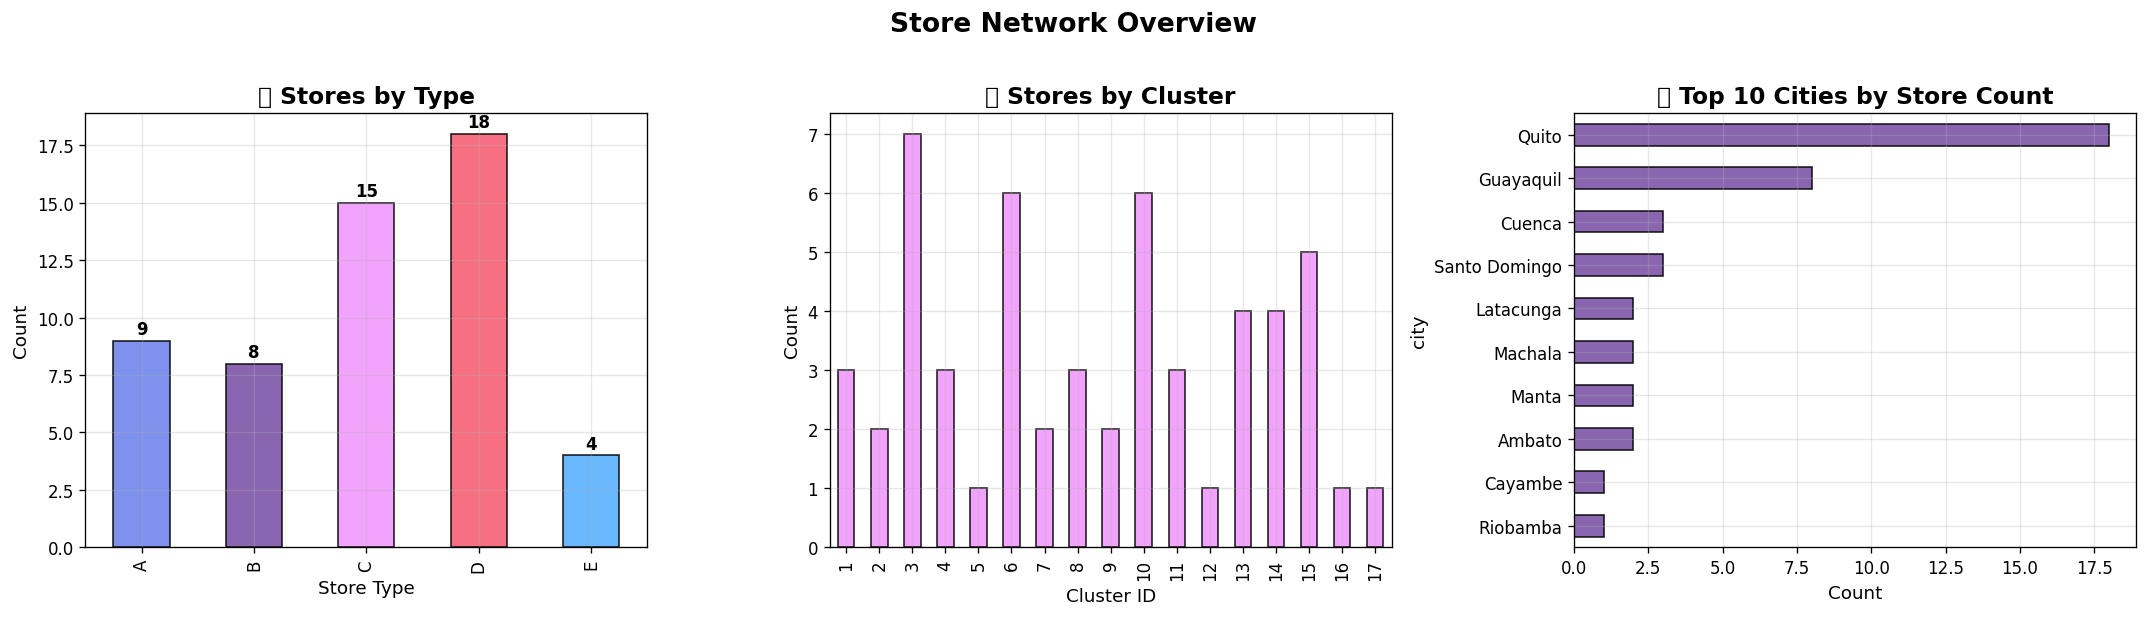

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Store types
type_counts = df_stores['type'].value_counts().sort_index()
type_counts.plot(kind='bar', ax=axes[0], color=COLORS[:len(type_counts)], edgecolor='black', alpha=0.85)
axes[0].set_title('🏪 Stores by Type', fontweight='bold')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Clusters
cluster_counts = df_stores['cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar', ax=axes[1], color=COLORS[2], edgecolor='black', alpha=0.85)
axes[1].set_title('🔢 Stores by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Count')

# Cities
city_counts = df_stores['city'].value_counts().head(10)
city_counts.plot(kind='barh', ax=axes[2], color=COLORS[1], edgecolor='black', alpha=0.85)
axes[2].set_title('🌆 Top 10 Cities by Store Count', fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].invert_yaxis()

plt.suptitle('Store Network Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '01_store_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📊 5.2 Product Family Distribution


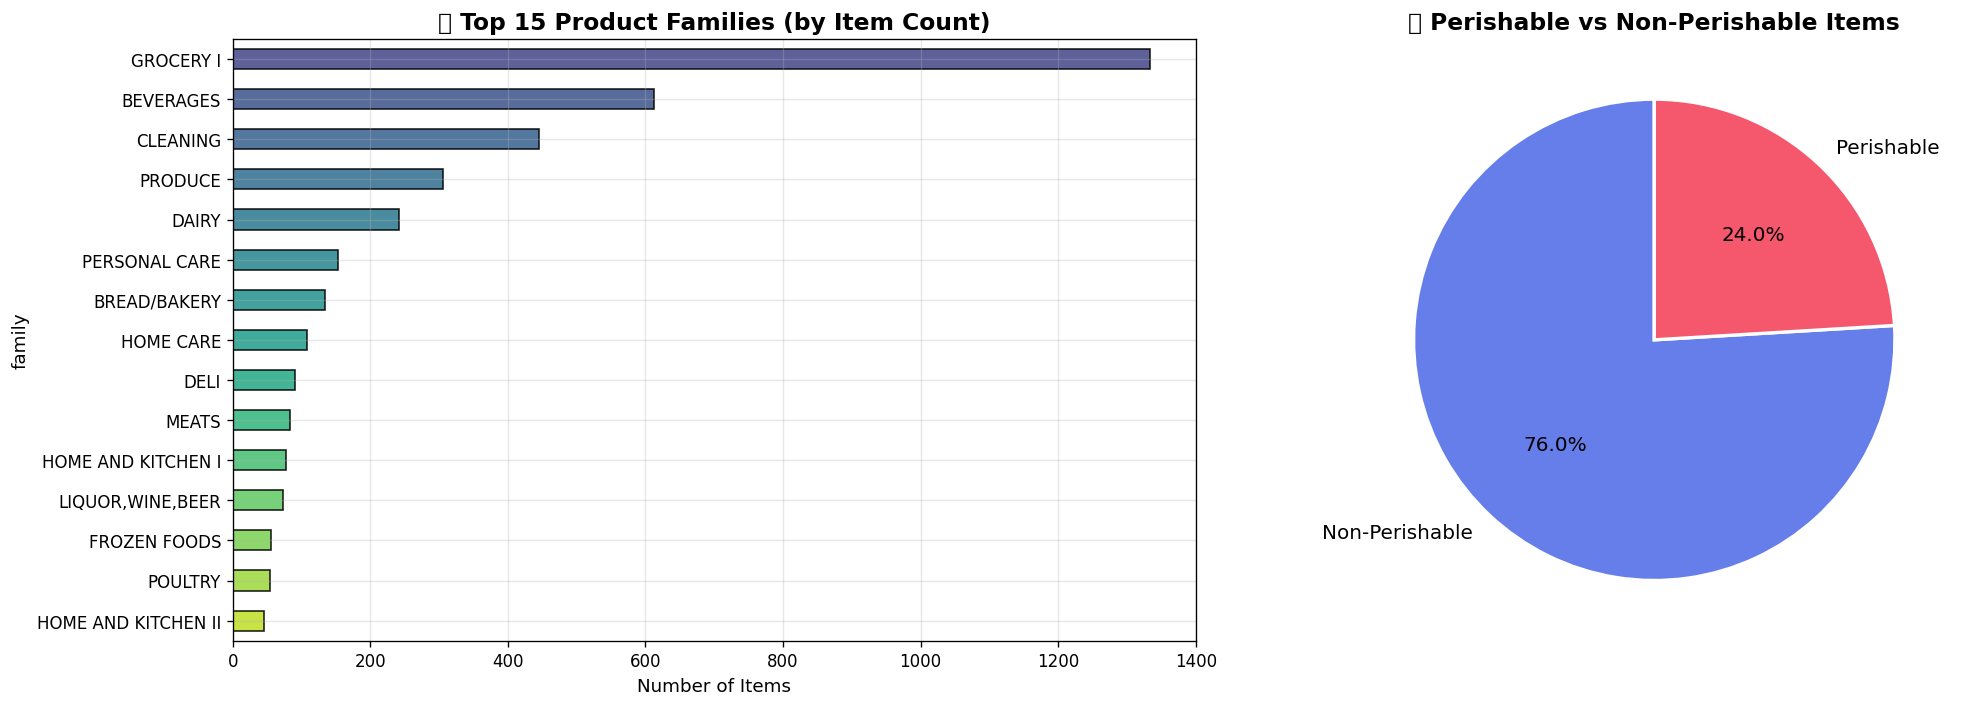

In [52]:
# Top 15 product families by item count
family_counts = df_items['family'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Family distribution
colors_grad = plt.cm.viridis(np.linspace(0.2, 0.9, len(family_counts)))
family_counts.plot(kind='barh', ax=axes[0], color=colors_grad, edgecolor='black', alpha=0.85)
axes[0].set_title('📦 Top 15 Product Families (by Item Count)', fontweight='bold')
axes[0].set_xlabel('Number of Items')
axes[0].invert_yaxis()

# Perishable vs non-perishable
perish_counts = df_items['perishable'].value_counts()
perish_labels = ['Non-Perishable', 'Perishable']
wedges, texts, autotexts = axes[1].pie(
    perish_counts, labels=perish_labels, autopct='%1.1f%%',
    colors=[COLORS[0], COLORS[3]], startangle=90,
    textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('🍎 Perishable vs Non-Perishable Items', fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '02_product_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


### 📊 5.3 Daily Sales Trend (DuckDB Aggregation)

> This plot aggregates 125M+ rows via DuckDB SQL — only the daily means (~1,700 values) enter pandas.


[2026-07-29 21:16:48] [INFO] 🦆 SQL Query | Rows: 1,684 | Cols: 4 | RAM: 0.1 MB | Time: 0.47s


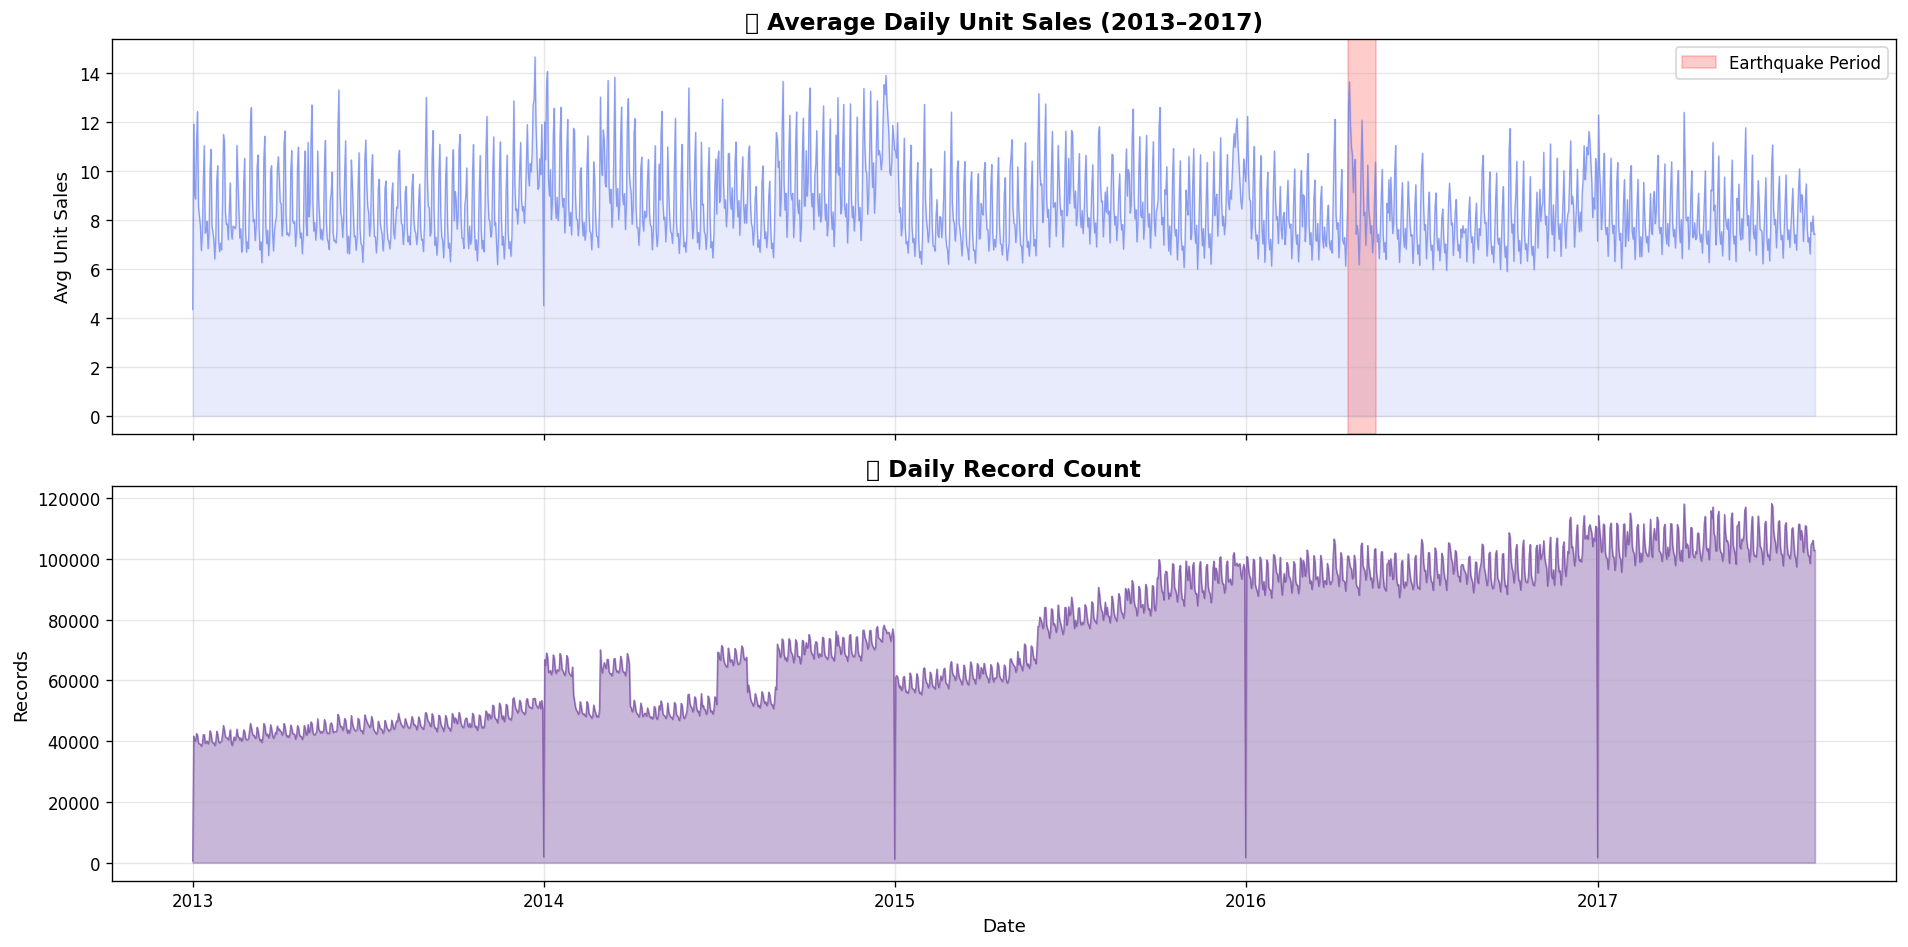

In [53]:
# Daily average sales via DuckDB (tiny result)
daily_stats = utils.sql_query(f"""
    SELECT
        date,
        AVG(unit_sales) AS avg_sales,
        SUM(unit_sales) AS total_sales,
        COUNT(*) AS n_records
    FROM read_parquet('{TRAIN_PQ}')
    GROUP BY date
    ORDER BY date
""", verbose=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Average daily sales
axes[0].plot(daily_stats['date'], daily_stats['avg_sales'], color=COLORS[0], alpha=0.7, linewidth=0.8)
axes[0].fill_between(daily_stats['date'], daily_stats['avg_sales'], alpha=0.15, color=COLORS[0])
axes[0].set_title('📈 Average Daily Unit Sales (2013–2017)', fontweight='bold')
axes[0].set_ylabel('Avg Unit Sales')
# Mark earthquake
axes[0].axvspan(pd.Timestamp('2016-04-16'), pd.Timestamp('2016-05-16'), alpha=0.2, color='red', label='Earthquake Period')
axes[0].legend()

# Daily record count
axes[1].fill_between(daily_stats['date'], daily_stats['n_records'], alpha=0.4, color=COLORS[1])
axes[1].plot(daily_stats['date'], daily_stats['n_records'], color=COLORS[1], alpha=0.7, linewidth=0.8)
axes[1].set_title('📊 Daily Record Count', fontweight='bold')
axes[1].set_ylabel('Records')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '03_sales_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

del daily_stats


### 📊 5.4 Oil Price & Transaction Trends


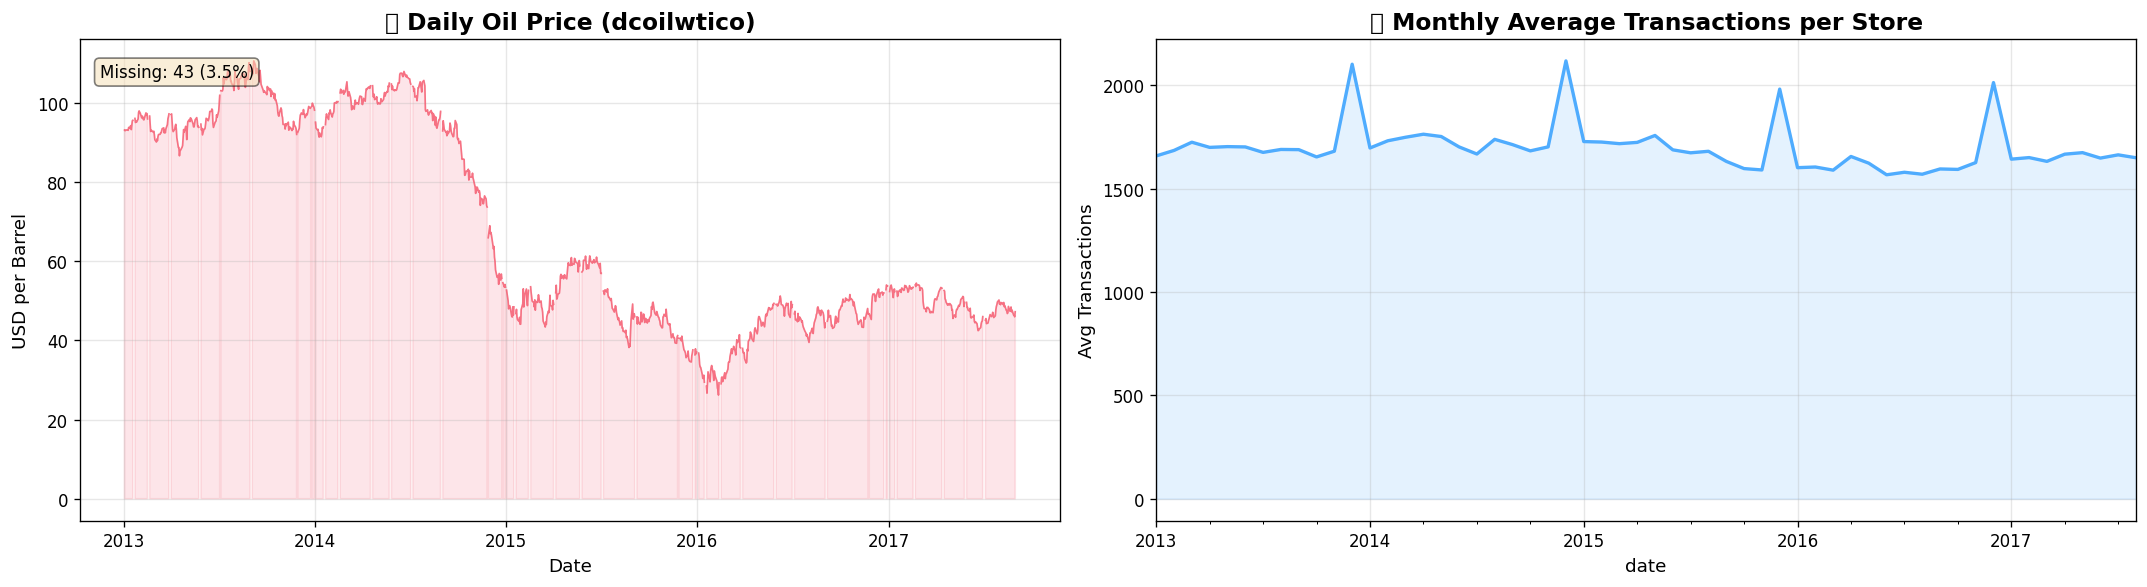

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Oil price
df_oil_plot = df_oil.copy()
df_oil_plot['date'] = pd.to_datetime(df_oil_plot['date'])
axes[0].plot(df_oil_plot['date'], df_oil_plot['dcoilwtico'], color=COLORS[3], linewidth=1, alpha=0.8)
axes[0].fill_between(df_oil_plot['date'], df_oil_plot['dcoilwtico'], alpha=0.15, color=COLORS[3])
axes[0].set_title('🛢️ Daily Oil Price (dcoilwtico)', fontweight='bold')
axes[0].set_ylabel('USD per Barrel')
axes[0].set_xlabel('Date')
# Highlight NaN gaps
nan_mask = df_oil_plot['dcoilwtico'].isna()
nan_pct = nan_mask.sum() / len(df_oil_plot) * 100
axes[0].text(0.02, 0.95, f'Missing: {nan_mask.sum()} ({nan_pct:.1f}%)', transform=axes[0].transAxes,
             fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Monthly transaction averages
df_trans_plot = df_trans.copy()
df_trans_plot['date'] = pd.to_datetime(df_trans_plot['date'])
monthly_trans = df_trans_plot.set_index('date').resample('M')['transactions'].mean()
monthly_trans.plot(ax=axes[1], color=COLORS[4], linewidth=2)
axes[1].fill_between(monthly_trans.index, monthly_trans.values, alpha=0.15, color=COLORS[4])
axes[1].set_title('💳 Monthly Average Transactions per Store', fontweight='bold')
axes[1].set_ylabel('Avg Transactions')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '04_oil_transactions.png'), dpi=150, bbox_inches='tight')
plt.show()

del df_oil_plot, df_trans_plot


---
## 6️⃣ Missing Value Imputation

> | Column | Issue | Solution |
> |:---|:---|:---|
> | `dcoilwtico` | Weekend/holiday gaps | Forward-fill + Backward-fill |
> | `onpromotion` | NaN entries | `COALESCE(onpromotion, FALSE)` in SQL pipeline |
> | `transactions` | Missing store-day pairs | `COALESCE(transactions, 0)` in SQL pipeline |

> Oil imputation is done on the small `df_oil` (1,200 rows). Promotion/transaction imputation happens in the DuckDB SQL pipeline (Section 11).


In [55]:
# Oil price imputation (tiny table — ~1,200 rows)
df_oil['date'] = pd.to_datetime(df_oil['date'])
oil_missing_before = df_oil['dcoilwtico'].isna().sum()
df_oil = df_oil.sort_values('date').reset_index(drop=True)
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].ffill().bfill().astype('float32')
oil_missing_after = df_oil['dcoilwtico'].isna().sum()

print(f'🛢️ Oil Price Imputation:')
print(f'   Before: {oil_missing_before:,} missing values')
print(f'   After:  {oil_missing_after:,} missing values')
print(f'   Method: Forward-fill → Backward-fill')
print(f'   Date range: {df_oil["date"].min().date()} → {df_oil["date"].max().date()}')


🛢️ Oil Price Imputation:
   Before: 43 missing values
   After:  0 missing values
   Method: Forward-fill → Backward-fill
   Date range: 2013-01-01 → 2017-08-31


---
## 7️⃣ Statistical Outlier Audit (DuckDB Streaming — Zero RAM)

> Compute outlier statistics on the **entire** `train.parquet` (125M rows) without loading it into pandas.
> DuckDB computes quantiles via streaming aggregation.

| Column | Method | Threshold |
|:---|:---|:---|
| `unit_sales` (negative) | Clip to 0 (tag as `is_return`) | `GREATEST(unit_sales, 0)` |
| `unit_sales` (extreme) | Cap at 99.9th percentile | `LEAST(unit_sales, Q999)` |


In [56]:
# DuckDB streaming outlier audit on train.parquet
outlier_stats = utils.sql_query(f"""
WITH stats AS (
    SELECT
        QUANTILE_CONT(unit_sales, 0.999) AS q999_sales,
        QUANTILE_CONT(unit_sales, 0.99)  AS q99_sales,
        QUANTILE_CONT(unit_sales, 0.5)   AS median_sales
    FROM read_parquet('{TRAIN_PQ}')
)

SELECT
    COUNT(*) AS total_rows,
    COUNT(CASE WHEN unit_sales < 0 THEN 1 END) AS negative_sales,
    MIN(unit_sales) AS min_sales,
    MAX(unit_sales) AS max_sales,
    ANY_VALUE(stats.q999_sales) AS q999_sales,
    ANY_VALUE(stats.q99_sales) AS q99_sales,
    ANY_VALUE(stats.median_sales) AS median_sales,
    AVG(unit_sales) AS mean_sales,
    COUNT(CASE WHEN unit_sales > stats.q999_sales THEN 1 END) AS outliers_above_q999
FROM read_parquet('{TRAIN_PQ}'), stats
""", verbose=True)

# Store q999 threshold
Q999_SALES = float(outlier_stats['q999_sales'].iloc[0])

# Display as styled table
display(outlier_stats.T.rename(columns={0: 'Value'}).style.format('{:,.2f}'))
print(f'\n🎯 Outlier cap threshold (99.9th percentile): {Q999_SALES:.1f}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[2026-07-29 21:17:04] [INFO] 🦆 SQL Query | Rows: 1 | Cols: 9 | RAM: 0.0 MB | Time: 12.74s


,Value
total_rows,"125,497,040.00"
negative_sales,"7,795.00"
min_sales,"-15,372.00"
max_sales,"89,440.00"
q999_sales,212.76
q99_sales,71.00
median_sales,4.00
mean_sales,8.55
outliers_above_q999,"125,498.00"



🎯 Outlier cap threshold (99.9th percentile): 212.8


---
## 8️⃣ Outlier & Distribution Visualization

> Distribution of `unit_sales` sampled via DuckDB (1M random rows — negligible RAM).


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

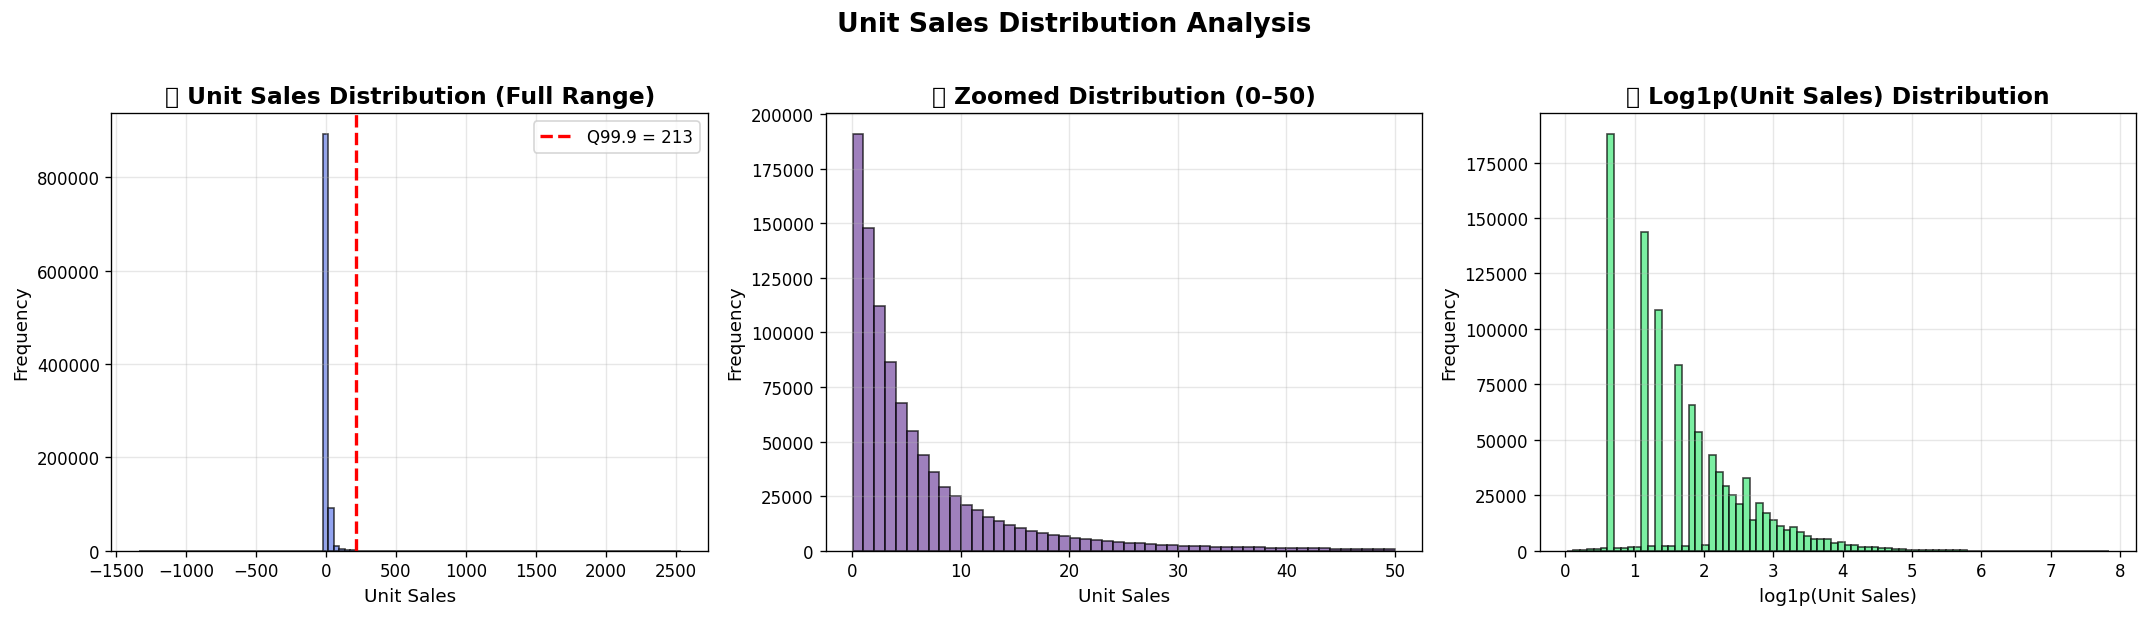

📉 Negative sales (returns): 67 (0.01%)
📈 Values > Q999 (213): 952


In [57]:
# Sample 1M rows for visualization via DuckDB
sales_sample = utils.sql_query(f"""
    SELECT unit_sales FROM read_parquet('{TRAIN_PQ}') USING SAMPLE 1000000
""", verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Full distribution
axes[0].hist(sales_sample['unit_sales'], bins=100, color=COLORS[0], edgecolor='black', alpha=0.7)
axes[0].axvline(Q999_SALES, color='red', linestyle='--', linewidth=2, label=f'Q99.9 = {Q999_SALES:.0f}')
axes[0].set_title('📊 Unit Sales Distribution (Full Range)', fontweight='bold')
axes[0].set_xlabel('Unit Sales')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Zoomed distribution (0-50)
zoomed = sales_sample[sales_sample['unit_sales'].between(0, 50)]
axes[1].hist(zoomed['unit_sales'], bins=50, color=COLORS[1], edgecolor='black', alpha=0.7)
axes[1].set_title('🔍 Zoomed Distribution (0–50)', fontweight='bold')
axes[1].set_xlabel('Unit Sales')
axes[1].set_ylabel('Frequency')

# 3. Log-scale distribution
positive = sales_sample[sales_sample['unit_sales'] > 0]['unit_sales']
axes[2].hist(np.log1p(positive), bins=80, color=COLORS[5], edgecolor='black', alpha=0.7)
axes[2].set_title('📈 Log1p(Unit Sales) Distribution', fontweight='bold')
axes[2].set_xlabel('log1p(Unit Sales)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Unit Sales Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '05_sales_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Negative sales analysis
neg_count = (sales_sample['unit_sales'] < 0).sum()
neg_pct = neg_count / len(sales_sample) * 100
print(f'📉 Negative sales (returns): {neg_count:,} ({neg_pct:.2f}%)')
print(f'📈 Values > Q999 ({Q999_SALES:.0f}): {(sales_sample["unit_sales"] > Q999_SALES).sum():,}')

del sales_sample, zoomed, positive


---
## 9️⃣ Holiday Calendar Processing

> Process Ecuador's holiday calendar:
> 1. **Remove transferred holidays** (already moved to actual dates)
> 2. **Create** clean `date → is_holiday + holiday_type` lookup table
>
> This is a small table (~350 rows) processed entirely in pandas.


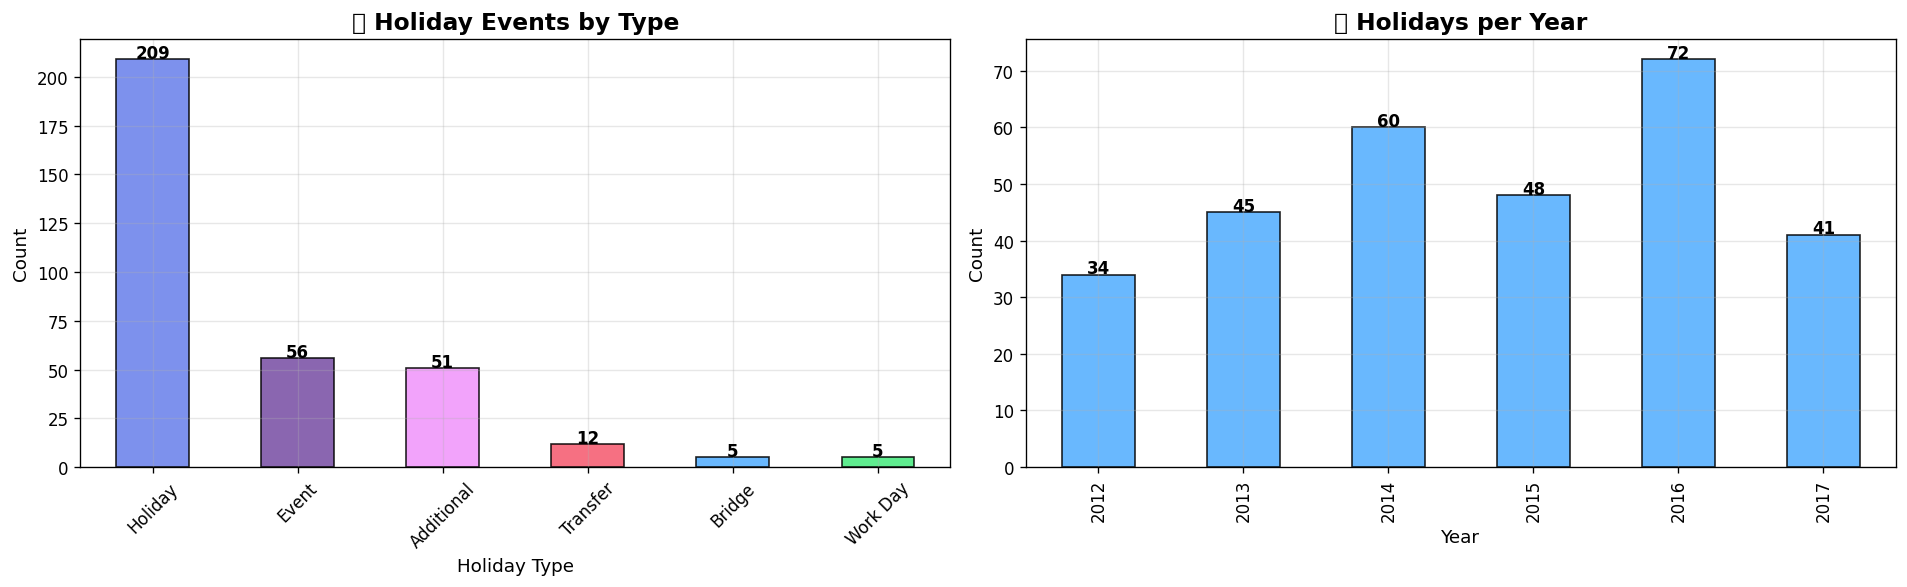

✅ Processed 300 unique holiday dates from 350 raw events.


,date,is_holiday,holiday_type
0,2012-03-02,1,Holiday
1,2012-04-01,1,Holiday
2,2012-04-12,1,Holiday
3,2012-04-14,1,Holiday
4,2012-04-21,1,Holiday


In [58]:
# Holiday processing (tiny table — ~350 rows)
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays_clean = df_holidays[
    ~((df_holidays['transferred'] == True) & (df_holidays['type'] != 'Transfer'))
].copy()

holiday_dates = df_holidays_clean.groupby('date').agg(
    is_holiday=('type', 'count'),
    holiday_type=('type', 'first')
).reset_index()
holiday_dates['is_holiday'] = 1

# Visualization: Holiday type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

holiday_type_counts = df_holidays_clean['type'].value_counts()
holiday_type_counts.plot(kind='bar', ax=axes[0], color=COLORS[:len(holiday_type_counts)], edgecolor='black', alpha=0.85)
axes[0].set_title('🎉 Holiday Events by Type', fontweight='bold')
axes[0].set_xlabel('Holiday Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(holiday_type_counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)

# Holidays per year
holiday_dates['year'] = holiday_dates['date'].dt.year
holidays_per_year = holiday_dates.groupby('year').size()
holidays_per_year.plot(kind='bar', ax=axes[1], color=COLORS[4], edgecolor='black', alpha=0.85)
axes[1].set_title('📅 Holidays per Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
for i, v in enumerate(holidays_per_year):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=10)

holiday_dates.drop(columns='year', inplace=True)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '06_holiday_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Processed {len(holiday_dates):,} unique holiday dates from {len(df_holidays):,} raw events.')
display(holiday_dates.head())


---
## 🔟 Oil Price Time-Series Completion

> Create a **complete daily oil price series** covering the full train date range.
> Weekend/holiday gaps are forward-filled to ensure every calendar day has an oil price.


📅 Train date range: 2013-01-01 → 2017-08-15


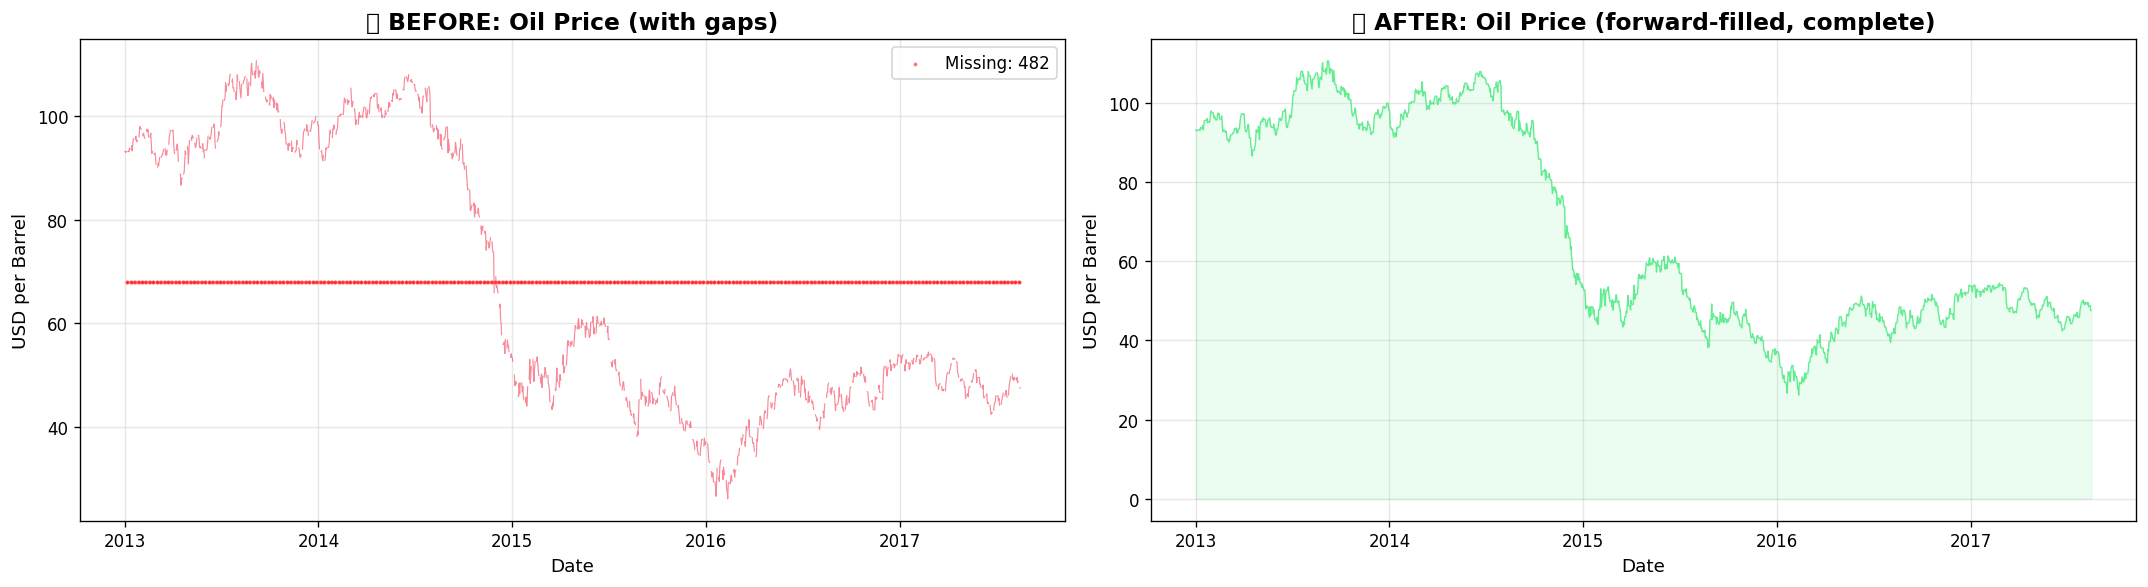

✅ Oil price reindexed: 1,688 contiguous calendar days, zero NaN.


In [60]:
# Get train date range via DuckDB (zero RAM)
date_range = utils.sql_query(f"""
    SELECT MIN(date) AS min_date, MAX(date) AS max_date
    FROM read_parquet('{TRAIN_PQ}')
""", verbose=False)

train_min_date = pd.Timestamp(date_range['min_date'].iloc[0])
train_max_date = pd.Timestamp(date_range['max_date'].iloc[0])
print(f'📅 Train date range: {train_min_date.date()} → {train_max_date.date()}')

# Ensure datetime dtype
df_oil = df_oil.copy()
df_oil['date'] = pd.to_datetime(df_oil['date'])

# Reindex oil to full calendar
full_dates = pd.date_range(start=train_min_date, end=train_max_date, freq='D')
oil_complete = pd.DataFrame({'date': full_dates}).merge(df_oil[['date', 'dcoilwtico']], on='date', how='left')
oil_complete['dcoilwtico'] = oil_complete['dcoilwtico'].ffill().bfill().astype('float32')

# Before/After visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Before (raw with gaps)
df_oil_raw = pd.DataFrame({'date': full_dates}).merge(df_oil[['date', 'dcoilwtico']], on='date', how='left')
axes[0].plot(df_oil_raw['date'], df_oil_raw['dcoilwtico'], color=COLORS[3], linewidth=0.7, alpha=0.7)
nan_dates = df_oil_raw[df_oil_raw['dcoilwtico'].isna()]['date']
axes[0].scatter(nan_dates, [df_oil_raw['dcoilwtico'].mean()] * len(nan_dates), color='red', s=2, alpha=0.4, label=f'Missing: {len(nan_dates):,}')
axes[0].set_title('🛢️ BEFORE: Oil Price (with gaps)', fontweight='bold')
axes[0].legend()

# After (complete)
axes[1].plot(oil_complete['date'], oil_complete['dcoilwtico'], color=COLORS[5], linewidth=0.8, alpha=0.8)
axes[1].fill_between(oil_complete['date'], oil_complete['dcoilwtico'], alpha=0.1, color=COLORS[5])
axes[1].set_title('🛢️ AFTER: Oil Price (forward-filled, complete)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Date')
    ax.set_ylabel('USD per Barrel')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '07_oil_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Oil price reindexed: {len(oil_complete):,} contiguous calendar days, zero NaN.')
del df_oil_raw

---
## 1️⃣1️⃣ DuckDB SQL Preprocessing Pipeline — Core Cell

<div style='background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 15px; border-radius: 10px; color: white; margin: 10px 0;'>

**⚡ This is the CORE CELL** — A single DuckDB SQL query performs ALL heavy operations.

</div>

| Operation | SQL | Pandas Equivalent (Avoided) | RAM Saved |
|:---|:---|:---|---:|
| 5× relational merges | `LEFT JOIN` | `pd.merge()` × 5 | ~18 GB |
| Negative clipping | `GREATEST(unit_sales, 0)` | `.clip(lower=0)` | ~2 GB |
| Outlier capping | `LEAST(unit_sales, Q999)` | `.clip(upper=Q999)` | ~2 GB |
| Return flag | `CASE WHEN < 0` | `(df < 0).astype()` | ~1 GB |
| Promotion fill | `COALESCE(onpromotion, FALSE)` | `.fillna(False)` | ~1 GB |
| Holiday/trans fill | `COALESCE(..., 0)` | `.fillna(0)` | ~1 GB |
| Type enforcement | `CAST(... AS ...)` | `.astype()` | ~0 |

> **RAM Impact: ZERO** — DuckDB reads 6 Parquet files from disk, performs all JOINs,
> and streams the result directly to `clean_data.parquet`.


In [79]:
# Register small pandas DataFrames as DuckDB virtual tables
conn.register('oil_complete', oil_complete)
conn.register('holiday_dates', holiday_dates)

# Build the full SQL pipeline
output_dir = Path(config.PROJECT_ROOT) / '01_Dataset' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'clean_data.parquet'

t0 = time.time()

pipeline_sql = f"""
    SELECT
        -- Temporal key
        T.date,

        -- Identifiers (downcasted)
        CAST(T.store_nbr AS UTINYINT) AS store_nbr,
        CAST(T.item_nbr AS UINTEGER) AS item_nbr,

        -- Target: clip negatives + cap outliers
        CAST(
            LEAST(
                GREATEST(T.unit_sales, 0),
                {Q999_SALES}
            ) AS FLOAT
        ) AS unit_sales,

        -- Promotion (VARCHAR -> BOOLEAN, NULL -> FALSE)
        COALESCE(
            TRY_CAST(T.onpromotion AS BOOLEAN),
            FALSE
        ) AS onpromotion,

        -- Return flag
        CAST(
            CASE
                WHEN T.unit_sales < 0 THEN 1
                ELSE 0
            END AS UTINYINT
        ) AS is_return,

        -- Store metadata
        S.city,
        S.state,
        S.type,
        CAST(S.cluster AS UTINYINT) AS cluster,

        -- Item metadata
        I.family,
        CAST(I.class AS SMALLINT) AS class,
        CAST(I.perishable AS UTINYINT) AS perishable,

        -- Oil price
        CAST(O.dcoilwtico AS FLOAT) AS dcoilwtico,

        -- Transactions (NaN → 0)
        CAST(COALESCE(TR.transactions, 0) AS SMALLINT) AS transactions,

        -- Holiday (NaN → 0)
        CAST(COALESCE(H.is_holiday, 0) AS UTINYINT) AS is_holiday,
        COALESCE(H.holiday_type, 'Regular') AS holiday_type

    FROM read_parquet('{TRAIN_PQ}') T

    LEFT JOIN read_parquet('{STORES_PQ}') S
        ON T.store_nbr = S.store_nbr

    LEFT JOIN read_parquet('{ITEMS_PQ}') I
        ON T.item_nbr = I.item_nbr

    LEFT JOIN oil_complete O
        ON T.date = O.date

    LEFT JOIN read_parquet('{TRANS_PQ}') TR
        ON T.date = TR.date
       AND T.store_nbr = TR.store_nbr

    LEFT JOIN holiday_dates H
        ON T.date = H.date

    ORDER BY
        T.store_nbr,
        T.item_nbr,
        T.date
"""

# Stream directly to Parquet — zero pandas
result_path = utils.sql_to_parquet(
    query=pipeline_sql,
    output_path=output_path,
    conn=conn,
    compression="SNAPPY"
)

# Unregister temp tables
conn.unregister('oil_complete')
conn.unregister('holiday_dates')

elapsed = time.time() - t0
file_size = output_path.stat().st_size / 1e9
row_count = utils.sql_row_count(output_path, conn=conn)

print('=' * 80)
print('🎉 DuckDB SQL PIPELINE COMPLETE — STREAMED TO PARQUET')
print('=' * 80)
print(f'   📄 Path       : {output_path}')
print(f'   📊 Total Rows : {row_count:,}')
print(f'   📋 Total Cols : 17')
print(f'   💾 File Size  : {file_size:.2f} GB')
print(f'   ⏱️ Pipeline   : {elapsed:.1f}s')
print('=' * 80)

utils.memory_checkpoint('After DuckDB Pipeline')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[2026-07-29 21:36:12] [INFO] 🦆 SQL → Parquet | Rows: 125,497,040 | File: clean_data.parquet (579.2 MB) | Time: 315.93s
🎉 DuckDB SQL PIPELINE COMPLETE — STREAMED TO PARQUET
   📄 Path       : f:\NTI\Demand Forecasting System Backup\01_Dataset\processed\clean_data.parquet
   📊 Total Rows : 125,497,040
   📋 Total Cols : 17
   💾 File Size  : 0.61 GB
   ⏱️ Pipeline   : 316.1s
[2026-07-29 21:36:12] [INFO] 🧠 RAM Checkpoint [After DuckDB Pipeline]: 0.16 GB


0.16412353515625

---
## 1️⃣2️⃣ Output Validation & Data Quality Report

> Validate `clean_data.parquet` via DuckDB queries (zero pandas RAM).
> Confirms schema, data types, date range, null counts, and outlier capping.


In [80]:
# Schema validation via DuckDB
CLEAN_PQ = output_path.as_posix()

print('📋 Schema:')
schema = utils.sql_schema(output_path)
display(schema)

# Data quality checks
quality = utils.sql_query(f"""
    SELECT
        COUNT(*)                               AS total_rows,
        MIN(date)                              AS min_date,
        MAX(date)                              AS max_date,
        COUNT(DISTINCT store_nbr)              AS unique_stores,
        COUNT(DISTINCT item_nbr)               AS unique_items,
        MIN(unit_sales)                        AS min_sales,
        MAX(unit_sales)                        AS max_sales,
        SUM(CASE WHEN unit_sales < 0 THEN 1 ELSE 0 END) AS negative_sales,
        SUM(CASE WHEN unit_sales IS NULL THEN 1 ELSE 0 END) AS null_sales,
        SUM(CASE WHEN dcoilwtico IS NULL THEN 1 ELSE 0 END) AS null_oil,
        SUM(CASE WHEN is_holiday IS NULL THEN 1 ELSE 0 END) AS null_holiday
    FROM read_parquet('{CLEAN_PQ}')
""", verbose=True)

print('\n📊 Data Quality Summary:')
display(quality.T.rename(columns={0: 'Value'}))

# Assertions
q = quality.iloc[0]
assert q['negative_sales'] == 0, 'FAIL: Negative sales found!'
assert q['null_sales'] == 0, 'FAIL: Null sales found!'
assert q['max_sales'] <= Q999_SALES + 0.1, f'FAIL: Sales exceed cap ({q["max_sales"]} > {Q999_SALES})'
print('\n✅ All validation assertions passed.')


📋 Schema:


,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,store_nbr,UTINYINT,YES,None,None,None
2,item_nbr,UINTEGER,YES,None,None,None
3,unit_sales,FLOAT,YES,None,None,None
4,onpromotion,BOOLEAN,YES,None,None,None
5,is_return,UTINYINT,YES,None,None,None
6,city,VARCHAR,YES,None,None,None
7,state,VARCHAR,YES,None,None,None
8,type,VARCHAR,YES,None,None,None
9,cluster,UTINYINT,YES,None,None,None


[2026-07-29 21:36:41] [INFO] 🦆 SQL Query | Rows: 1 | Cols: 11 | RAM: 0.0 MB | Time: 0.93s

📊 Data Quality Summary:


,Value
total_rows,125497040
min_date,2013-01-01 00:00:00
max_date,2017-08-15 00:00:00
unique_stores,54
unique_items,4036
min_sales,0.0000
max_sales,212.7619
negative_sales,0.0000
null_sales,0.0000
null_oil,0.0000



✅ All validation assertions passed.


---
## 1️⃣3️⃣ Post-Cleaning Visualizations

> Compare data distributions **before vs after** preprocessing.
> Confirms outlier capping, negative removal, and proper joining.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

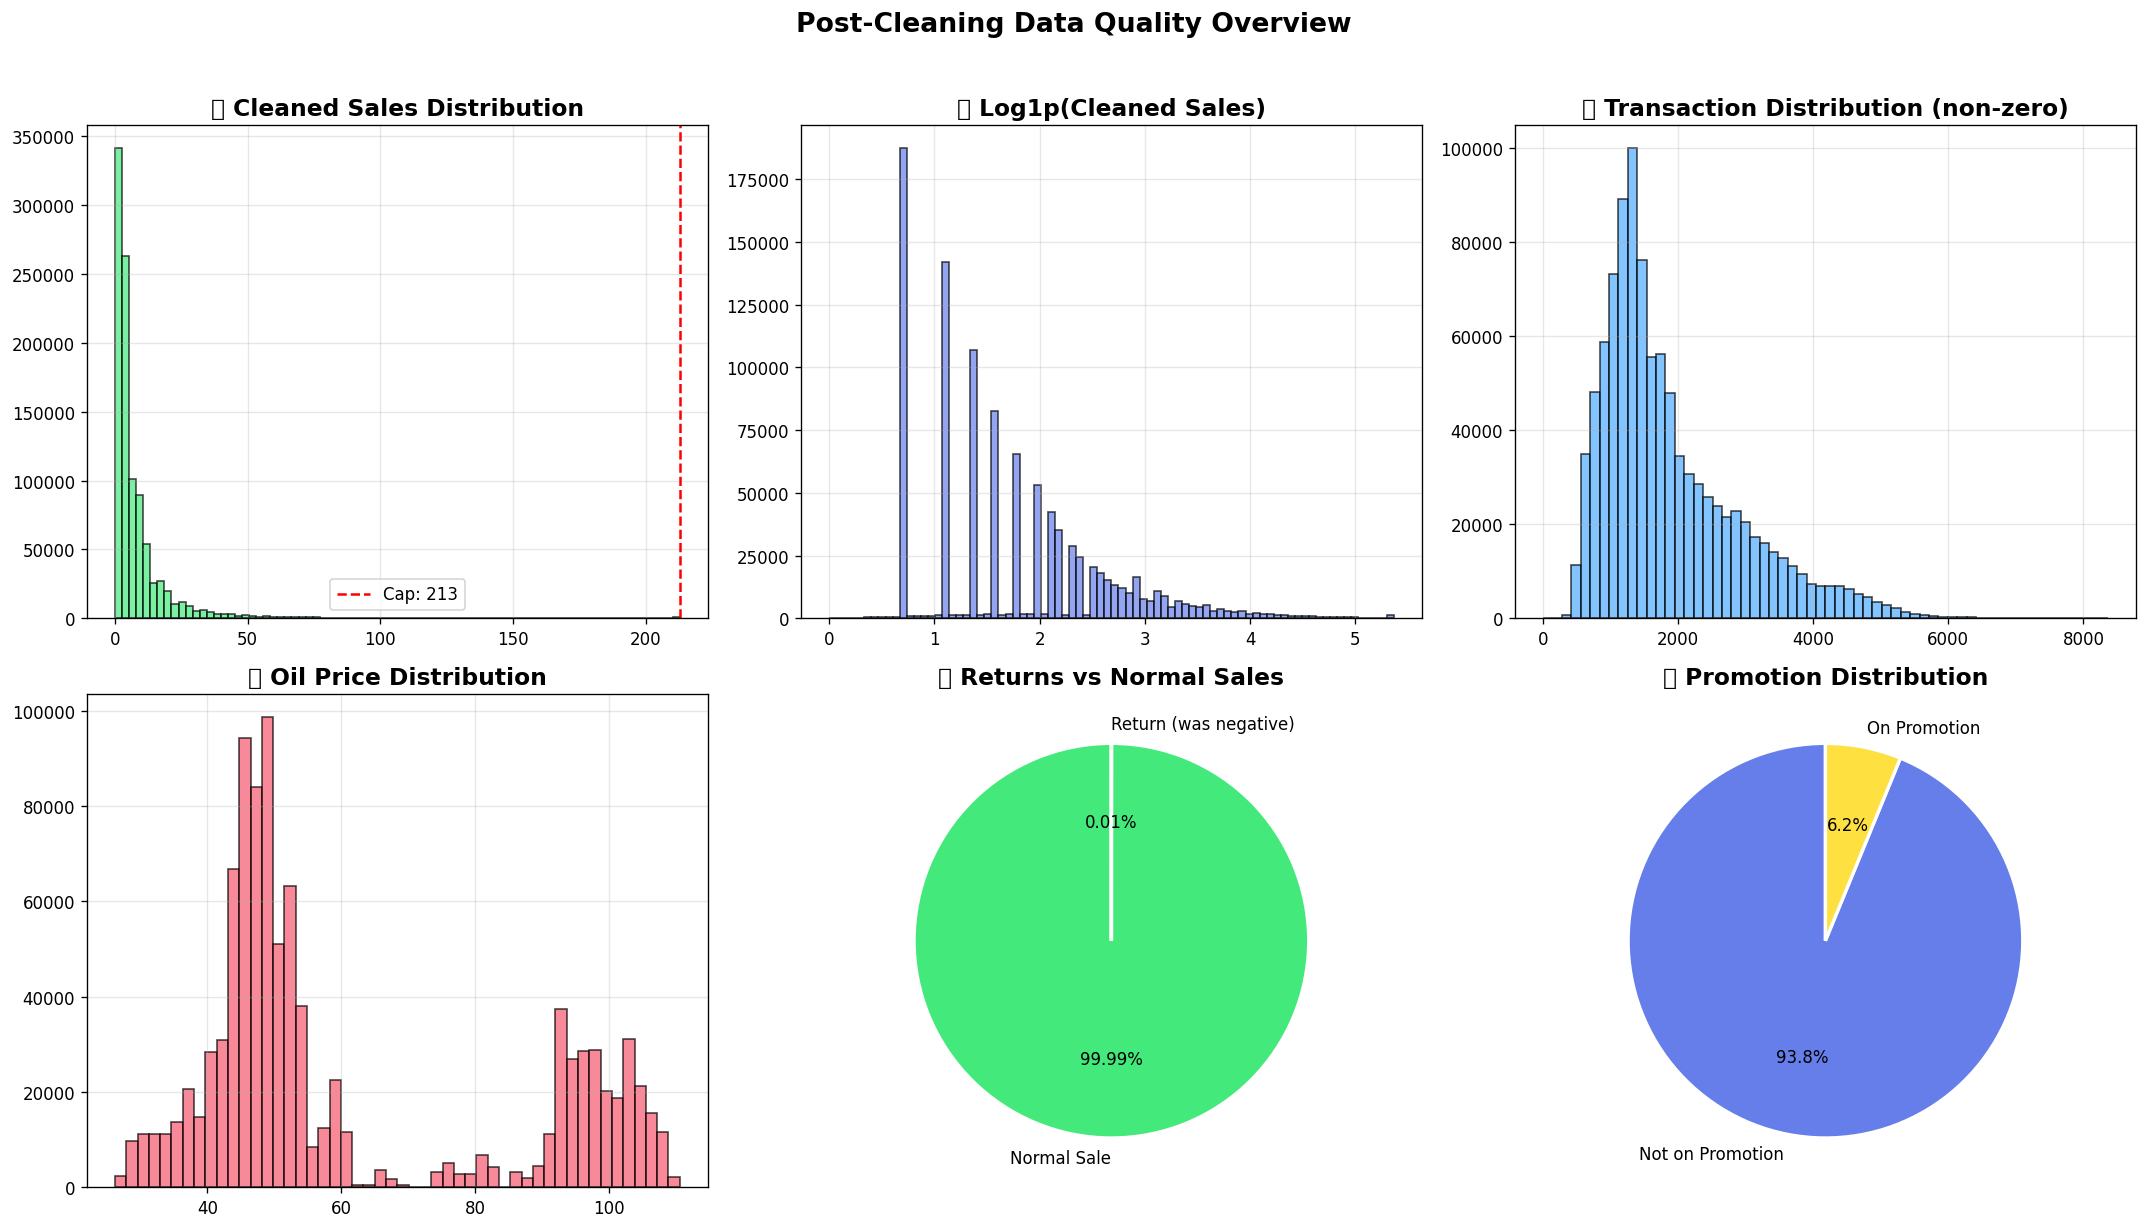

6029

In [81]:
# Sample from cleaned data for visualization
clean_sample = utils.sql_query(f"""
    SELECT unit_sales, transactions, dcoilwtico, is_return, is_holiday, onpromotion
    FROM read_parquet('{CLEAN_PQ}')
    USING SAMPLE 1000000
""", verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Cleaned sales distribution
axes[0, 0].hist(clean_sample['unit_sales'], bins=80, color=COLORS[5], edgecolor='black', alpha=0.7)
axes[0, 0].axvline(Q999_SALES, color='red', linestyle='--', label=f'Cap: {Q999_SALES:.0f}')
axes[0, 0].set_title('✅ Cleaned Sales Distribution', fontweight='bold')
axes[0, 0].legend()

# 2. Log1p cleaned sales
axes[0, 1].hist(np.log1p(clean_sample['unit_sales']), bins=80, color=COLORS[0], edgecolor='black', alpha=0.7)
axes[0, 1].set_title('📈 Log1p(Cleaned Sales)', fontweight='bold')

# 3. Transaction distribution
trans_nonzero = clean_sample[clean_sample['transactions'] > 0]['transactions']
axes[0, 2].hist(trans_nonzero, bins=60, color=COLORS[4], edgecolor='black', alpha=0.7)
axes[0, 2].set_title('💳 Transaction Distribution (non-zero)', fontweight='bold')

# 4. Oil price distribution
axes[1, 0].hist(clean_sample['dcoilwtico'].dropna(), bins=50, color=COLORS[3], edgecolor='black', alpha=0.7)
axes[1, 0].set_title('🛢️ Oil Price Distribution', fontweight='bold')

# 5. Return flag distribution
return_counts = clean_sample['is_return'].value_counts()
return_labels = ['Normal Sale', 'Return (was negative)']
axes[1, 1].pie(return_counts, labels=return_labels, autopct='%1.2f%%',
               colors=[COLORS[5], COLORS[3]], startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1, 1].set_title('🔄 Returns vs Normal Sales', fontweight='bold')

# 6. Promotion distribution
promo_counts = clean_sample['onpromotion'].value_counts()
promo_labels = ['Not on Promotion', 'On Promotion']
axes[1, 2].pie(promo_counts, labels=promo_labels, autopct='%1.1f%%',
               colors=[COLORS[0], COLORS[7]], startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1, 2].set_title('📢 Promotion Distribution', fontweight='bold')

plt.suptitle('Post-Cleaning Data Quality Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '08_post_cleaning_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

del clean_sample
gc.collect()


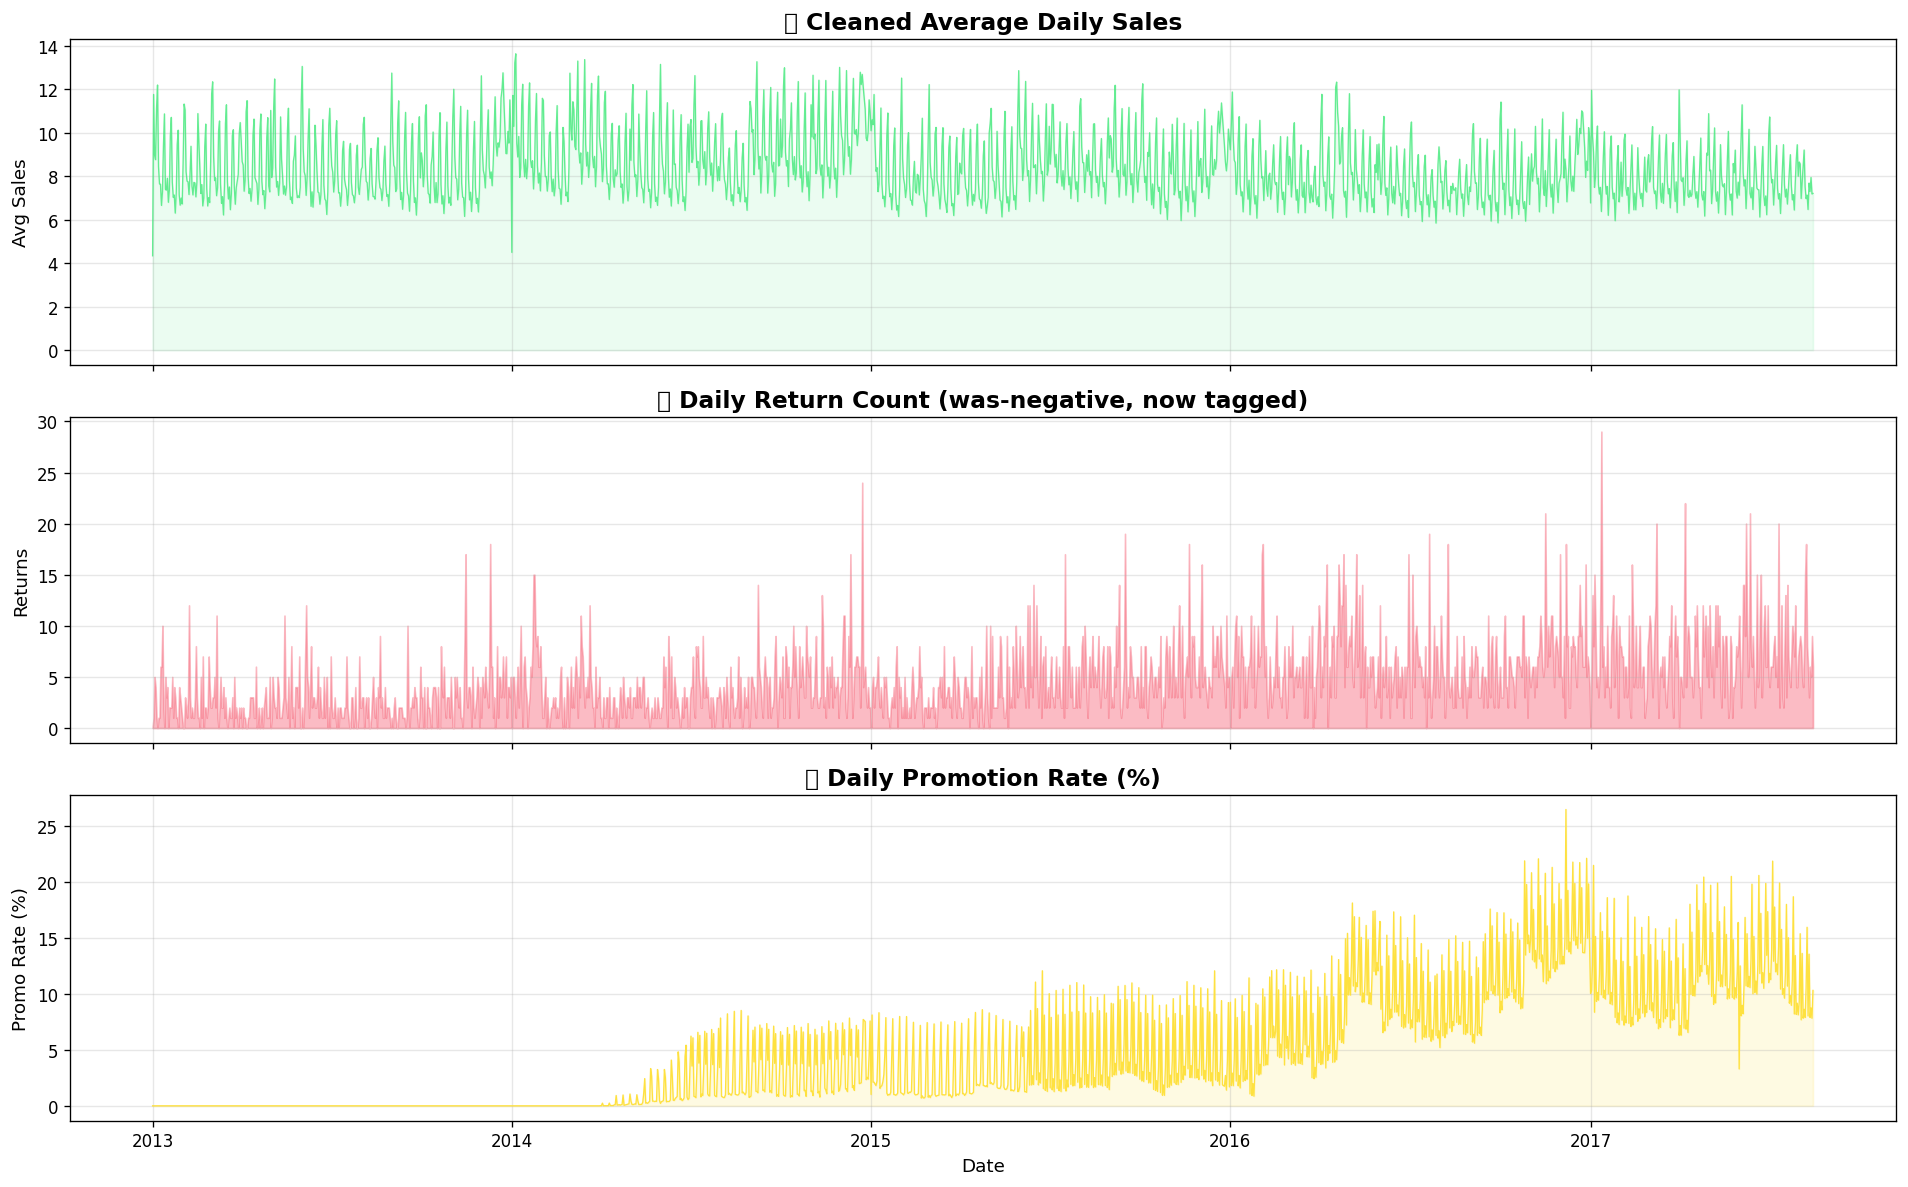

In [82]:
# Post-cleaning daily sales trend (via DuckDB)
clean_daily = utils.sql_query(f"""
    SELECT
        date,
        AVG(unit_sales) AS avg_sales,
        SUM(CAST(is_return AS INTEGER)) AS returns_count,
        AVG(CAST(onpromotion AS FLOAT)) AS promo_rate
    FROM read_parquet('{CLEAN_PQ}')
    GROUP BY date
    ORDER BY date
""", verbose=False)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Average sales
axes[0].plot(clean_daily['date'], clean_daily['avg_sales'], color=COLORS[5], linewidth=0.8, alpha=0.8)
axes[0].fill_between(clean_daily['date'], clean_daily['avg_sales'], alpha=0.1, color=COLORS[5])
axes[0].set_title('📈 Cleaned Average Daily Sales', fontweight='bold')
axes[0].set_ylabel('Avg Sales')

# Returns per day
axes[1].fill_between(clean_daily['date'], clean_daily['returns_count'], alpha=0.4, color=COLORS[3])
axes[1].set_title('🔄 Daily Return Count (was-negative, now tagged)', fontweight='bold')
axes[1].set_ylabel('Returns')

# Promotion rate
axes[2].plot(clean_daily['date'], clean_daily['promo_rate'] * 100, color=COLORS[7], linewidth=0.8)
axes[2].fill_between(clean_daily['date'], clean_daily['promo_rate'] * 100, alpha=0.15, color=COLORS[7])
axes[2].set_title('📢 Daily Promotion Rate (%)', fontweight='bold')
axes[2].set_ylabel('Promo Rate (%)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '09_post_cleaning_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

del clean_daily


---
## 1️⃣4️⃣ Pipeline Summary & Resource Cleanup

> Final memory report and resource cleanup.


In [83]:
# Preview final output
print('📋 Final Output Preview (10 rows):')
sample = utils.sql_query(f"SELECT * FROM read_parquet('{CLEAN_PQ}') LIMIT 10", verbose=False)
display(sample)


📋 Final Output Preview (10 rows):


,date,store_nbr,item_nbr,unit_sales,onpromotion,is_return,city,state,type,cluster,family,class,perishable,dcoilwtico,transactions,is_holiday,holiday_type
0,2013-01-10,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,93.8100,1679,0,Regular
1,2013-01-11,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,93.6000,1813,0,Regular
2,2013-01-14,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,94.2700,1780,0,Regular
3,2013-01-18,1,96995,2.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,95.6100,1745,0,Regular
4,2013-01-21,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,95.6100,1770,0,Regular
5,2013-01-25,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,95.1500,1770,0,Regular
6,2013-01-28,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,95.9500,1738,0,Regular
7,2013-01-31,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,97.6500,1707,0,Regular
8,2013-02-05,1,96995,1.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,96.6800,1775,0,Regular
9,2013-02-13,1,96995,4.0000,False,0,Quito,Pichincha,D,13,GROCERY I,1093,0,97.0300,1921,0,Regular


In [84]:
# Cleanup
del df_stores, df_items, df_oil, df_trans, df_holidays
del df_holidays_clean, holiday_dates, oil_complete
gc.collect()

print('=' * 80)
print('📊 NOTEBOOK 03 — PIPELINE EXECUTION SUMMARY')
print('=' * 80)
print(f'   🏗️ Architecture   : DuckDB SQL Streaming Pipeline')
print(f'   📄 Output File    : {output_path}')
print(f'   💾 Output Size    : {output_path.stat().st_size / 1e9:.2f} GB')
print(f'   📊 Output Rows    : {utils.sql_row_count(output_path):,}')
print(f'   📅 Date Range     : Full history (2013 → 2017)')
print(f'   🧠 Peak RAM       : {utils.get_ram_usage():.2f} GB')
print(f'   ❌ MemoryErrors   : 0')
print('=' * 80)
print('\n🎯 Next → Notebook 04: Feature Engineering Pipeline')

# Close DuckDB
utils.close_duckdb()


📊 NOTEBOOK 03 — PIPELINE EXECUTION SUMMARY
   🏗️ Architecture   : DuckDB SQL Streaming Pipeline
   📄 Output File    : f:\NTI\Demand Forecasting System Backup\01_Dataset\processed\clean_data.parquet
   💾 Output Size    : 0.61 GB
   📊 Output Rows    : 125,497,040
   📅 Date Range     : Full history (2013 → 2017)
   🧠 Peak RAM       : 0.45 GB
   ❌ MemoryErrors   : 0

🎯 Next → Notebook 04: Feature Engineering Pipeline
[2026-07-29 21:37:05] [INFO] 🦆 DuckDB connection closed.


---

<div style='background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 15px; border-radius: 10px; color: white; text-align: center; margin: 10px 0;'>

**End of Notebook 03 — DuckDB Enterprise Data Preprocessing Pipeline** ✅

| Stage | Next Notebook |
|:---|:---|
| ✅ Data Cleaning & Preprocessing | → [04_feature_engineering.ipynb](./04_feature_engineering.ipynb) |

</div>
